In [ ]:
#Basic package
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import joblib
import sys
import io
from dotenv import load_dotenv


In [36]:
from sklearn.preprocessing import MinMaxScaler

In [2]:
#Model package
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
datapath = '../dataset/VN30_dataset.csv'
dataset=pd.read_csv(datapath)

#dataset["Market Capital (Bn VND)"] = dataset["Market Capital (Bn VND)"] / 1_000_000_000

#Sử dụng minmaxscaler cho vốn hóa 
scaler = MinMaxScaler()
dataset["Market Capital (Bn VND)"] = scaler.fit_transform(
    dataset[["Market Capital (Bn VND)"]]
)
#
dataset = dataset.sort_values(["ticker", "time"])
dataset["return_1"] = (
    dataset
    .groupby("ticker")["close"]
    .transform(lambda x: np.log(x) - np.log(x.shift(1)))
)

### Implementing OLS model for evaluate the significance of variables

In [38]:
#Buidling the feature
dataset = dataset.fillna(0)
y = dataset["return_30"]

features = [
    "MA20","MA50","RSI","Vol20","Vol60",
    "ROA (%)","ROE (%)","EPS (VND)","BVPS (VND)",
    "Debt/Equity","Financial Leverage",
    "Net Profit Margin (%)",
    "P/E","P/B","P/S","P/Cash Flow",
    "Market Capital (Bn VND)",
    "volume"
]

X = dataset[features]




***Same pattern for the whole dataset. We testing the signigicant (coef) of the exogs for the significance level with the return rolling 30 days of all stocks***

In [39]:
model = sm.OLS(y, X).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:              return_30   R-squared (uncentered):                   0.628
Model:                            OLS   Adj. R-squared (uncentered):              0.628
Method:                 Least Squares   F-statistic:                              4858.
Date:                Mon, 02 Feb 2026   Prob (F-statistic):                        0.00
Time:                        17:06:31   Log-Likelihood:                          60625.
No. Observations:               51872   AIC:                                 -1.212e+05
Df Residuals:                   51854   BIC:                                 -1.211e+05
Df Model:                          18                                                  
Covariance Type:            nonrobust                                                  
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

In [6]:
# Kiểm tra tính đa cộng tuyến cho mô hình 
X_mc = sm.add_constant(X)

vif = pd.DataFrame({
    "feature": X_mc.columns,
    "VIF": [variance_inflation_factor(X_mc.values, i) for i in range(X_mc.shape[1])]
})

cond_number = np.linalg.cond(X_mc.values)

print(vif.sort_values("VIF", ascending=False))
print("Condition Number:", cond_number)

                    feature          VIF
11       Financial Leverage  4499.738097
10              Debt/Equity  4493.114861
0                     const   206.717430
1                      MA20   181.958118
2                      MA50   177.797185
4                     Vol20    14.778763
5                     Vol60    11.052024
6                   ROA (%)     4.636788
18                   volume     4.144856
7                   ROE (%)     4.117010
14                      P/B     3.781436
8                 EPS (VND)     3.017828
9                BVPS (VND)     2.511046
12    Net Profit Margin (%)     2.183729
17  Market Capital (Bn VND)     1.556153
15                      P/S     1.496502
13                      P/E     1.227199
3                       RSI     1.105577
16              P/Cash Flow     1.018002
Condition Number: 661507174.0811228


Variance inflation factors reveal severe multicollinearity, particularly among leverage-related ratios and moving-average indicators.

In [40]:
filtered_features = [
    "MA20",
     #"MA50",
    "RSI",
    #"Vol20",
    "Vol60",
   # "ROA (%)",
   "ROE (%)",
   "EPS (VND)",
   #"BVPS (VND)",
    # "Debt/Equity",
   # "Financial Leverage" ,
    #"Net Profit Margin (%)",
    "P/E",
    "P/B","P/S","P/Cash Flow",
    "Market Capital (Bn VND)",
   "volume"
]
y1 = dataset["return_30"]
X1 = dataset[filtered_features]

In [ ]:
df = dataset[["time", "ticker", "return_30"] + filtered_features].sort_values("time")

split = int(len(df) * 0.7)

train = df.iloc[:split]
test = df.iloc[split:]

y_train = train["return_30"]
X_train = train[filtered_features]

y_test = test["return_30"]
X_test = test[filtered_features]

model2 = sm.OLS(y_train, X_train).fit()

y_pred = model2.predict(X_test)

summary_df = pd.DataFrame({
    "time": test["time"].values,
    "ticker": test["ticker"].values,
    "y_true": y_test.values,
    "y_pred": y_pred.values
})

print(model2.summary())


                                 OLS Regression Results                                
Dep. Variable:              return_30   R-squared (uncentered):                   0.224
Model:                            OLS   Adj. R-squared (uncentered):              0.223
Method:                 Least Squares   F-statistic:                              950.0
Date:                Mon, 02 Feb 2026   Prob (F-statistic):                        0.00
Time:                        17:06:39   Log-Likelihood:                          27153.
No. Observations:               36310   AIC:                                 -5.428e+04
Df Residuals:                   36299   BIC:                                 -5.419e+04
Df Model:                          11                                                  
Covariance Type:            nonrobust                                                  
                              coef    std err          t      P>|t|      [0.025      0.975]
----------------------------

In [33]:

load_dotenv(override=True)

results_path = os.getenv("RESULTS_PATH")
output_path = os.path.join(results_path, "OLS_prediction.xlsx")

summary_df.to_excel(output_path, index=False)

In [43]:
mae = (summary_df["y_true"] - summary_df["y_pred"]).abs().mean()
mae


np.float64(0.06740964038214149)

 There is no more multinecollarity

In [9]:
X1_vif = sm.add_constant(X1)

vif_df = pd.DataFrame({
    "feature": X1_vif.columns,
    "VIF": [variance_inflation_factor(X1_vif.values, i) for i in range(X1_vif.shape[1])]
})

vif_df.sort_values("VIF", ascending=False)

,feature,VIF
0,const,18.609856
3,Vol60,3.128922
11,volume,3.089709
7,P/B,2.689417
1,MA20,2.669299
4,ROE (%),2.234519
5,EPS (VND),2.153684
10,Market Capital (Bn VND),1.234815
6,P/E,1.215040
8,P/S,1.107999


<Figure size 640x480 with 0 Axes>

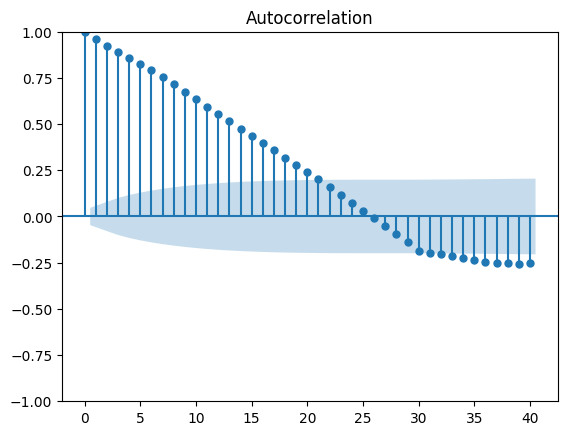

<Figure size 640x480 with 0 Axes>

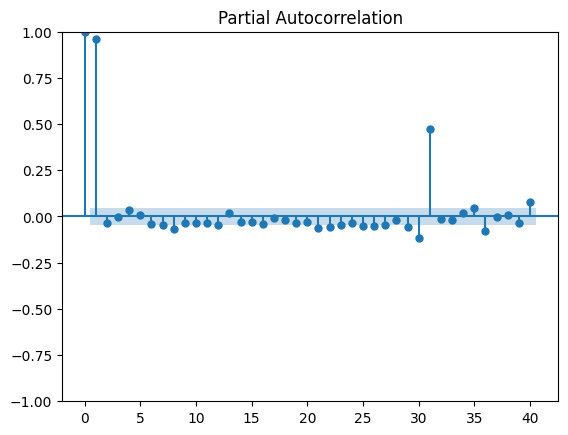

In [10]:
ts = (
    dataset[dataset["ticker"] == "VCB"]   # chọn 1 ticker
    .sort_values("time")["return_30"]
    .dropna()
)

plt.figure()
plot_acf(ts, lags=40)
plt.show()

plt.figure()
plot_pacf(ts, lags=40, method="ywm")
plt.show()